In [1]:
import numpy as np
import time
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score
import pandas as pd
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import FunctionTransformer, RobustScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.utils.class_weight import compute_class_weight
import seaborn as sns
from sklearn.model_selection import StratifiedKFold
from sklearn.datasets import make_classification, make_circles

SEED = 42
np.random.seed(SEED)

csv_path = "../../../data/raw/classification/covtype.csv"

df = pd.read_csv(csv_path)

target_col = "Cover_Type"

X = df.drop(columns=[target_col]).copy()
y = df[target_col].copy()

continuous_cols = X.columns[:10].tolist()
wilderness_cols = [c for c in X.columns if c.startswith("Wilderness_Area")]
soil_cols = [c for c in X.columns if c.startswith("Soil_Type")]
binary_cols = wilderness_cols + soil_cols

In [2]:
X_temp_raw, X_test_raw, y_temp, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=SEED,
    stratify=y,
)

# Val chiếm 10% tổng dữ liệu -> 12.5% trên tập tạm (80%)
X_train_raw, X_val_raw, y_train, y_val = train_test_split(
    X_temp_raw,
    y_temp,
    test_size=0.125,
    random_state=SEED,
    stratify=y_temp,
)

# Preprocessing pipeline

In [3]:
class IQROutlierClipper(BaseEstimator, TransformerMixin):
    """Clip outliers theo IQR cho từng cột continuous, fit trên train để tránh leakage."""

    def __init__(self, whisker_width=1.5):
        self.whisker_width = whisker_width
        self.lower_bounds_ = None
        self.upper_bounds_ = None
        self.columns_ = None

    def fit(self, X, _y=None):
        _ = _y
        if not isinstance(X, pd.DataFrame):
            X = pd.DataFrame(X)
        self.columns_ = X.columns.tolist()
        q1 = X.quantile(0.25)
        q3 = X.quantile(0.75)
        iqr = q3 - q1
        self.lower_bounds_ = q1 - self.whisker_width * iqr
        self.upper_bounds_ = q3 + self.whisker_width * iqr
        return self

    def transform(self, X):
        if not isinstance(X, pd.DataFrame):
            X = pd.DataFrame(X, columns=self.columns_)
        return X.clip(lower=self.lower_bounds_, upper=self.upper_bounds_, axis=1)

In [4]:
def add_engineered_features(X_input: pd.DataFrame) -> pd.DataFrame:
    """Tạo đặc trưng mới từ nhóm khoảng cách địa lý."""
    X_out = X_input.copy()

    # Khoảng cách Euclid đến thủy văn
    X_out["Euclidean_Distance_To_Hydrology"] = np.sqrt(
        X_out["Horizontal_Distance_To_Hydrology"] ** 2
        + X_out["Vertical_Distance_To_Hydrology"] ** 2
    )

    # Khoảng cách trung bình tới các tiện ích địa lý quan trọng
    X_out["Distance_To_Amenities"] = (
        X_out["Horizontal_Distance_To_Roadways"]
        + X_out["Horizontal_Distance_To_Fire_Points"]
        + X_out["Euclidean_Distance_To_Hydrology"]
    ) / 3.0

    return X_out

feature_engineer = FunctionTransformer(add_engineered_features, validate=False)



# Danh sách continuous mở rộng sau khi tạo đặc trưng
continuous_features_final = continuous_cols + [
    "Euclidean_Distance_To_Hydrology",
    "Distance_To_Amenities",
]

# Pipeline cho nhóm continuous: clip outlier trước, sau đó scale
continuous_pipeline = Pipeline(
    steps=[
        ("iqr_clip", IQROutlierClipper(whisker_width=1.5)),
        ("scaler", RobustScaler()),
    ]
)

# ColumnTransformer kết hợp biến đổi theo nhóm cột
preprocessor = ColumnTransformer(
    transformers=[
        ("continuous", continuous_pipeline, continuous_features_final),
        ("binary", "passthrough", binary_cols),
    ],
    remainder="drop",
)

# Pipeline đầy đủ: FE -> ColumnTransformer
preprocess_pipeline = Pipeline(
    steps=[
        ("feature_engineering", feature_engineer),
        ("column_transform", preprocessor),
    ]
)

# Fit trên train và transform val/test để tránh leakage
X_train_processed = preprocess_pipeline.fit_transform(X_train_raw)
X_val_processed = preprocess_pipeline.transform(X_val_raw)
X_test_processed = preprocess_pipeline.transform(X_test_raw)

y_train_np = y_train.to_numpy()
y_val_np = y_val.to_numpy()
y_test_np = y_test.to_numpy()

In [5]:
classes = np.sort(y_train.unique())
weights = compute_class_weight(class_weight="balanced", classes=classes, y=y_train)
class_weight_dict = {int(cls): float(w) for cls, w in zip(classes, weights)}
sample_weight_train = y_train.map(class_weight_dict).to_numpy()

In [6]:
print("\nThống kê sample_weight_train:")
print("Min:", sample_weight_train.min())
print("Max:", sample_weight_train.max())
print("Mean:", sample_weight_train.mean())

print("\nKích thước dữ liệu sau preprocess:")
print("X_train_processed:", X_train_processed.shape)
print("X_val_processed:", X_val_processed.shape)
print("X_test_processed:", X_test_processed.shape)
print("y_train:", y_train.shape)
print("y_val:", y_val.shape)
print("y_test:", y_test.shape)


Thống kê sample_weight_train:
Min: 0.2929806868034895
Max: 30.213728549141965
Mean: 1.0000000000000002

Kích thước dữ liệu sau preprocess:
X_train_processed: (406707, 56)
X_val_processed: (58102, 56)
X_test_processed: (116203, 56)
y_train: (406707,)
y_val: (58102,)
y_test: (116203,)


## **Task 1: Logistic Regression & Optimization**

### Mathematical Derivation: Jacobian and Hessian of the Softmax Function

For a multiclass classification problem with $K$ classes, the output of the network for the $k$-th class is given by the Softmax function:
$$y_k = \frac{\exp(z_k)}{\sum_{j=1}^K \exp(z_j)}$$
where $z_i$ represents the logit (pre-activation) for class $i$.

**The Jacobian (Gradient of Softmax):**
We need to find $\frac{\partial y_k}{\partial z_i}$. There are two cases to consider:
1.  **When $k = i$:**
    $$\frac{\partial y_k}{\partial z_k} = \frac{\exp(z_k)\sum_{j} \exp(z_j) - \exp(z_k)\exp(z_k)}{\left(\sum_{j} \exp(z_j)\right)^2} = y_k(1 - y_k)$$
2.  **When $k \neq i$:**
    $$\frac{\partial y_k}{\partial z_i} = \frac{0 - \exp(z_k)\exp(z_i)}{\left(\sum_{j} \exp(z_j)\right)^2} = -y_k y_i$$

Combining these using the Kronecker delta $\delta_{ki}$ (which is 1 if $k=i$ and 0 otherwise), the Jacobian matrix elements are:
$$\frac{\partial y_k}{\partial z_i} = y_k(\delta_{ki} - y_i)$$

**The Hessian of the Cross-Entropy Loss:**
Given the multiclass cross-entropy loss $E = -\sum_{k} t_k \ln y_k$, the gradient with respect to the weight vector $w_j$ is $\nabla_{w_j} E = \sum_{n=1}^N (y_{nj} - t_{nj}) x_n$. 
The Hessian matrix $H$ is the second derivative of the loss with respect to the weights. For a specific block of the Hessian relating class $k$ and class $j$:
$$H_{kj} = \nabla_{w_k} \nabla_{w_j} E = \sum_{n=1}^N x_n \frac{\partial y_{nk}}{\partial z_{nj}} x_n^T$$
Substituting the Jacobian derived above:
$$H_{kj} = \sum_{n=1}^N x_n (y_{nk}(\delta_{kj} - y_{nj})) x_n^T$$
This shows that the Hessian is positive semi-definite, ensuring the loss landscape is strictly convex.

In [7]:
class LogisticRegression:
    """
    An implementation of Logistic Regression supporting:
    - Binary classification via Gradient Descent and Newton-Raphson (IRLS).
    - Multiclass classification via Gradient Descent (Softmax).
    """
    def __init__(self, learning_rate: float = 0.01, max_iter: int = 100, tol: float = 1e-4):
        self.learning_rate = learning_rate
        self.max_iter = max_iter
        self.tol = tol
        self.weights = None
        self.history = {'loss': [], 'time': []}
        self.epsilon = 1e-15
        self.classes_ = None
        
    def _sigmoid(self, z):
        return 1 / (1 + np.exp(-np.clip(z, -250, 250))) 
    
    def _softmax(self, z):
        exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))
        return exp_z / np.sum(exp_z, axis=1, keepdims=True)
    
    def _add_intercept(self, X):
        return np.hstack((np.ones((X.shape[0], 1)), X))
    
    def fit_gd_binary(self, X, y):
        X_pad = self._add_intercept(X)
        N, D = X_pad.shape
        self.weights = np.zeros(D)
        start_time = time.time()
        
        for i in range(self.max_iter):
            z = np.dot(X_pad, self.weights)
            y_pred = self._sigmoid(z)
            
            loss = -np.mean(y * np.log(y_pred + self.epsilon) + (1 - y) * np.log(1 - y_pred + self.epsilon))
            
            gradient = np.dot(X_pad.T, (y_pred - y)) / N
            self.weights -= self.learning_rate * gradient
            
            self.history['loss'].append(loss)
            self.history['time'].append(time.time() - start_time)
            
            if np.linalg.norm(gradient) < self.tol:
                break
        return self
                
    def fit_newton_binary(self, X, y):
        """Iteratively Reweighted Least Squares (IRLS)"""
        X_pad = self._add_intercept(X)
        N, D = X_pad.shape
        self.weights = np.zeros(D)
        start_time = time.time()
        
        for i in range(self.max_iter):
            y_pred = self._sigmoid(np.dot(X_pad, self.weights))
            
            loss = -np.mean(y * np.log(y_pred + self.epsilon) + (1 - y) * np.log(1 - y_pred + self.epsilon))
            self.history['loss'].append(loss)
            self.history['time'].append(time.time() - start_time)
            

            r = y_pred * (1 - y_pred) 
            gradient = np.dot(X_pad.T, (y_pred - y))
            Hessian = np.dot(X_pad.T, r[:, np.newaxis] * X_pad)
            
            Hessian += np.eye(D) * 1e-5
            
            try:
                update = np.linalg.solve(Hessian, gradient)
                self.weights -= update
            except np.linalg.LinAlgError:
                print("Singular matrix encountered. Stopping IRLS.")
                break
                
            if np.linalg.norm(update) < self.tol:
                break
        return self

    def fit_gd_multiclass(self, X, y):
        X_pad = self._add_intercept(X)
        N, D = X_pad.shape
        self.classes_ = np.unique(y)
        K = len(self.classes_)
        
        class_to_idx = {c: i for i, c in enumerate(self.classes_)}
        y_idx = np.array([class_to_idx[label] for label in y])
        
        y_one_hot = np.zeros((N, K))
        y_one_hot[np.arange(N), y_idx] = 1
        
        self.weights = np.zeros((D, K))
        start_time = time.time()
        
        for i in range(self.max_iter):
            z = np.dot(X_pad, self.weights)
            y_pred = self._softmax(z)
            
            loss = -np.sum(y_one_hot * np.log(y_pred + self.epsilon)) / N
            gradient = np.dot(X_pad.T, (y_pred - y_one_hot)) / N
            self.weights -= self.learning_rate * gradient
            
            self.history['loss'].append(loss)
            self.history['time'].append(time.time() - start_time)
        return self

    def predict_proba(self, X):
        X_pad = self._add_intercept(X)
        if self.weights.ndim == 1:
            return self._sigmoid(np.dot(X_pad, self.weights))
        else:
            return self._softmax(np.dot(X_pad, self.weights))
            
    def predict(self, X, threshold=0.5):
        probs = self.predict_proba(X)
        if self.weights.ndim == 1:
            return (probs >= threshold).astype(int)
        else:
            # Map back to original class labels
            class_indices = np.argmax(probs, axis=1)
            return self.classes_[class_indices]


class OneVsRestClassifierCustom:
    def __init__(self, learning_rate=0.01, max_iter=1000, tol=1e-4):
        self.learning_rate = learning_rate
        self.max_iter = max_iter
        self.tol = tol
        self.models = []
        self.classes_ = None

    def fit(self, X, y):
        self.classes_ = np.unique(y)
        self.models = []
        for c in self.classes_:
            # Create binary target: 1 for current class, 0 for all others
            y_binary = np.where(y == c, 1, 0)
            model = LogisticRegression(self.learning_rate, self.max_iter, self.tol)
            model.fit_gd_binary(X, y_binary)
            self.models.append(model)
        return self

    def predict(self, X):
        probs = np.zeros((X.shape[0], len(self.classes_)))
        for idx, model in enumerate(self.models):
            probs[:, idx] = model.predict_proba(X)
        return self.classes_[np.argmax(probs, axis=1)]


class OneVsOneClassifierCustom:
    def __init__(self, learning_rate=0.01, max_iter=1000, tol=1e-4):
        self.learning_rate = learning_rate
        self.max_iter = max_iter
        self.tol = tol
        self.models = {}
        self.classes_ = None

    def fit(self, X, y):
        self.classes_ = np.unique(y)
        n_classes = len(self.classes_)
        for i in range(n_classes):
            for j in range(i + 1, n_classes):
                c1, c2 = self.classes_[i], self.classes_[j]
                
                # Filter dataset for only these two classes
                mask = (y == c1) | (y == c2)
                X_filtered, y_filtered = X[mask], y[mask]
                y_binary = np.where(y_filtered == c1, 1, 0)
                
                model = LogisticRegression(self.learning_rate, self.max_iter, self.tol)
                model.fit_gd_binary(X_filtered, y_binary)
                self.models[(c1, c2)] = model
        return self

    def predict(self, X):
        votes = np.zeros((X.shape[0], len(self.classes_)))
        
        for (c1, c2), model in self.models.items():
            probs = model.predict_proba(X)
            preds = np.where(probs >= 0.5, c1, c2)
            
            # Tally votes
            for idx, p in enumerate(preds):
                class_idx = np.where(self.classes_ == p)[0][0]
                votes[idx, class_idx] += 1
                
        return self.classes_[np.argmax(votes, axis=1)]

In [8]:
y_train_binary = np.where(y_train == 1, 1, 0)

print("\nTraining Binary Models for Convergence Plot")
gd_binary_model = LogisticRegression(learning_rate=0.1, max_iter=100).fit_gd_binary(X_train_processed, y_train_binary)
newton_binary_model = LogisticRegression(max_iter=10).fit_newton_binary(X_train_processed, y_train_binary)


Training Binary Models for Convergence Plot


In [9]:
def plot_convergence(model_gd, model_newton):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # Loss vs Epochs
    ax1.plot(model_gd.history['loss'], label='Gradient Descent', color='blue')
    ax1.plot(model_newton.history['loss'], label='Newton-Raphson', color='red')
    ax1.set_xlabel('Epochs / Iterations')
    ax1.set_ylabel('Binary Cross-Entropy Loss')
    ax1.set_title('Loss vs. Iterations')
    ax1.legend()
    
    # Loss vs Wall-clock time
    ax2.plot(model_gd.history['time'], model_gd.history['loss'], label='Gradient Descent', color='blue')
    ax2.plot(model_newton.history['time'], model_newton.history['loss'], label='Newton-Raphson', color='red')
    ax2.set_xlabel('Wall-clock Time (seconds)')
    ax2.set_ylabel('Binary Cross-Entropy Loss')
    ax2.set_title('Loss vs. Time')
    ax2.legend()
    
    plt.tight_layout()
    plt.show()

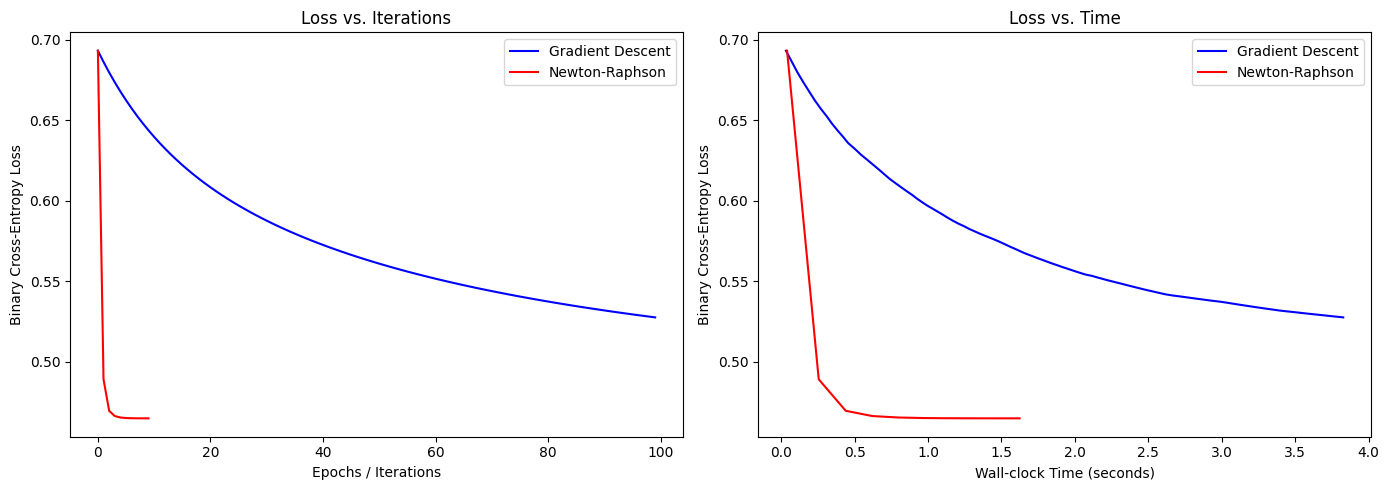

In [10]:
plot_convergence(gd_binary_model, newton_binary_model)

In [11]:
def evaluate_multiclass_strategies(X_train, y_train, X_val, y_val):
    print("Training One-vs-Rest...")
    ovr = OneVsRestClassifierCustom(learning_rate=0.1, max_iter=500).fit(X_train, y_train)

    print("Training One-vs-One...")
    ovo = OneVsOneClassifierCustom(learning_rate=0.1, max_iter=500).fit(X_train, y_train)

    print("Training Direct Softmax...")
    softmax_model = LogisticRegression(learning_rate=0.1, max_iter=500).fit_gd_multiclass(X_train, y_train)

    strategies = {
        "One-vs-Rest": ovr,
        "One-vs-One": ovo,
        "Direct Softmax": softmax_model,
    }

    scores = {}
    val_predictions = {}
    for name, model in strategies.items():
        y_pred = model.predict(X_val)
        score = f1_score(y_val, y_pred, average='macro')
        scores[name] = float(score)
        val_predictions[name] = np.asarray(y_pred)
        print(f"{name} Macro-F1 Score: {score:.4f}")

    return {
        "scores": scores,
        "models": strategies,
        "val_predictions": val_predictions,
    }

In [12]:
print("Evaluating Multiclass Strategies")
multiclass_output = evaluate_multiclass_strategies(
    X_train_processed,
    y_train_np,
    X_val_processed,
    y_val_np,
)

multiclass_results = multiclass_output["scores"]
multiclass_models = multiclass_output["models"]
multiclass_val_predictions = multiclass_output["val_predictions"]

Evaluating Multiclass Strategies
Training One-vs-Rest...
Training One-vs-One...
Training Direct Softmax...
One-vs-Rest Macro-F1 Score: 0.2861
One-vs-One Macro-F1 Score: 0.3351
Direct Softmax Macro-F1 Score: 0.2993


## **Task 2: LDA vs. QDA**

### 2.1 Implementing Discriminant Analysis and Fisher Ratio

In [13]:
class LinearDiscriminantAnalysis:
    def __init__(self, n_components=None):
        self.n_components = n_components
        self.priors_ = None
        self.means_ = None
        self.coef_ = None
        self.intercept_ = None
        self.scalings_ = None 
        self.classes_ = None

    def fit(self, X, y):
        self.classes_ = np.unique(y)
        n_samples, n_features = X.shape
        n_classes = len(self.classes_)

        self.priors_ = np.zeros(n_classes)
        self.means_ = np.zeros((n_classes, n_features))

        # 1. Calculate priors and class means
        for i, c in enumerate(self.classes_):
            X_c = X[y == c]
            self.priors_[i] = X_c.shape[0] / n_samples
            self.means_[i, :] = np.mean(X_c, axis=0)

        # 2. Calculate Shared Covariance Matrix (Sw)
        Sw = np.zeros((n_features, n_features))
        for i, c in enumerate(self.classes_):
            X_c = X[y == c]
            diff = X_c - self.means_[i, :]
            Sw += np.dot(diff.T, diff)
        
        Sigma = Sw / (n_samples - n_classes)
        Sigma += np.eye(n_features) * 1e-6 #  numerical stability
        Sigma_inv = np.linalg.pinv(Sigma)

        # 3. Parameters for Classification (Linear Decision Boundary)
        self.coef_ = np.dot(self.means_, Sigma_inv)
        self.intercept_ = -0.5 * np.diag(np.dot(self.means_, np.dot(Sigma_inv, self.means_.T))) + np.log(self.priors_)

        # 4. Parameters for Dimensionality Reduction (Sb and Eigen decomposition)
        global_mean = np.mean(X, axis=0)
        Sb = np.zeros((n_features, n_features))
        for i, c in enumerate(self.classes_):
            N_c = X[y == c].shape[0]
            mean_diff = (self.means_[i, :] - global_mean).reshape(-1, 1)
            Sb += N_c * np.dot(mean_diff, mean_diff.T)

        # Solve eigenvalue problem: Sw^-1 * Sb
        A = np.dot(np.linalg.pinv(Sw), Sb)
        eigenvalues, eigenvectors = np.linalg.eig(A)

        # Sort eigenvectors by eigenvalues in descending order
        eigenvectors = eigenvectors.T
        idxs = np.argsort(abs(eigenvalues))[::-1]
        eigenvectors = eigenvectors[idxs]

        # Store eigenvectors for projection
        if self.n_components is not None:
            self.scalings_ = np.real(eigenvectors[0:self.n_components].T)
        else:
            self.scalings_ = np.real(eigenvectors.T)

        return self

    def predict(self, X):
        """Linear score function: delta_c(x) = Wx + b"""
        scores = np.dot(X, self.coef_.T) + self.intercept_
        return self.classes_[np.argmax(scores, axis=1)]

    def transform(self, X):
        """Project data into lower dimensional space"""
        return np.dot(X, self.scalings_)

    def fit_transform(self, X, y):
        self.fit(X, y)
        return self.transform(X)

In [14]:
class QuadraticDiscriminantAnalysis:
    def __init__(self):
        self.priors_ = None
        self.means_ = None
        self.cov_invs_ = None
        self.log_dets_ = None
        self.classes_ = None

    def fit(self, X, y):
        self.classes_ = np.unique(y)
        n_samples, n_features = X.shape
        n_classes = len(self.classes_)

        self.priors_ = np.zeros(n_classes)
        self.means_ = np.zeros((n_classes, n_features))
        self.cov_invs_ = []
        self.log_dets_ = []

        for i, c in enumerate(self.classes_):
            X_c = X[y == c]
            self.priors_[i] = X_c.shape[0] / n_samples
            self.means_[i, :] = np.mean(X_c, axis=0)

            # Separate Covariance matrix for each class c
            diff = X_c - self.means_[i, :]
            cov = np.dot(diff.T, diff) / (X_c.shape[0] - 1)
            cov += np.eye(n_features) * 1e-6 # numerical stability
            
            self.cov_invs_.append(np.linalg.pinv(cov))
            
            # Compute log determinant
            sign, logdet = np.linalg.slogdet(cov)
            self.log_dets_.append(logdet)

        return self

    def predict(self, X):
        n_samples = X.shape[0]
        n_classes = len(self.classes_)
        scores = np.zeros((n_samples, n_classes))

        # Quadratic score function
        for i in range(n_classes):
            diff = X - self.means_[i, :]
            # Vectorized quadratic term computation: (x-u)^T * Sigma^-1 * (x-u)
            term1 = -0.5 * self.log_dets_[i]
            term2 = -0.5 * np.sum(np.dot(diff, self.cov_invs_[i]) * diff, axis=1)
            term3 = np.log(self.priors_[i])
            scores[:, i] = term1 + term2 + term3

        return self.classes_[np.argmax(scores, axis=1)]

In [15]:
print("Training LDA ...")
lda = LinearDiscriminantAnalysis()
lda.fit(X_train_processed, y_train_np)
preds_lda = lda.predict(X_test_processed)
print(f"Macro-F1 Score: {f1_score(y_test_np, preds_lda, average='macro'):.4f}")

print("Training QDA ...")
qda = QuadraticDiscriminantAnalysis()
qda.fit(X_train_processed, y_train_np)
preds_qda = qda.predict(X_test_processed)
print(f"Macro-F1 Score: {f1_score(y_test_np, preds_qda, average='macro'):.4f}")

# Lưu xác suất để phục vụ PR/AP và calibration ở notebook 04
scores_lda = np.dot(X_test_processed, lda.coef_.T) + lda.intercept_
exp_scores_lda = np.exp(scores_lda - np.max(scores_lda, axis=1, keepdims=True))
proba_lda = exp_scores_lda / np.sum(exp_scores_lda, axis=1, keepdims=True)

n_classes = len(qda.classes_)
scores_qda = np.zeros((X_test_processed.shape[0], n_classes))
for i in range(n_classes):
    diff = X_test_processed - qda.means_[i, :]
    term1 = -0.5 * qda.log_dets_[i]
    term2 = -0.5 * np.sum(np.dot(diff, qda.cov_invs_[i]) * diff, axis=1)
    term3 = np.log(qda.priors_[i])
    scores_qda[:, i] = term1 + term2 + term3
exp_scores_qda = np.exp(scores_qda - np.max(scores_qda, axis=1, keepdims=True))
proba_qda = exp_scores_qda / np.sum(exp_scores_qda, axis=1, keepdims=True)

Training LDA ...
Macro-F1 Score: 0.5123
Training QDA ...
Macro-F1 Score: 0.2335


### **2.2 Feature Ranking via the Fisher Ratio**
To understand which features are driving the model's decisions, we utilize the Fisher Ratio, denoted as $J(w)$. This ratio assesses the discriminative power of individual features by comparing the variance *between* the classes to the variance *within* the classes. 

Mathematically, for a single feature, it is defined as:
$$J = \frac{\sum_{c} N_c (\mu_{c} - \mu_{global})^2}{\sum_c N_c \sigma_{c}^2}$$

A higher Fisher Ratio indicates that a feature has class means that are spread far apart relative to the internal scatter of the classes. Such features are highly discriminative because they naturally separate the target categories along that axis.


In [16]:
def calculate_fisher_ratio(X, y):
    """
    Calculates the Fisher ratio J(w) for each feature to rank discriminative power.
    J = (Between-class variance) / (Within-class variance)
    """
    classes = np.unique(y)
    global_mean = np.mean(X, axis=0)
    
    between_class_var = np.zeros(X.shape[1])
    within_class_var = np.zeros(X.shape[1])
    
    for c in classes:
        X_c = X[y == c]
        N_c = X_c.shape[0]
        class_mean = np.mean(X_c, axis=0)
        class_var = np.var(X_c, axis=0)
        
        between_class_var += N_c * (class_mean - global_mean)**2
        within_class_var += N_c * class_var
        
    fisher_ratios = between_class_var / (within_class_var + 1e-15)
    return fisher_ratios

In [17]:
print("\nCalculating Fisher Ratios...")
fisher_scores = calculate_fisher_ratio(X_train_processed, y_train_np)
top_indices = np.argsort(fisher_scores)[::-1][:5]
print("Top 5 Feature Indices by Discriminative Power:", top_indices)
print("Top 5 Fisher Ratios:", fisher_scores[top_indices])


Calculating Fisher Ratios...
Top 5 Feature Indices by Discriminative Power: [ 0 15 25 11 19]
Top 5 Fisher Ratios: [1.56199257 1.19668737 0.290805   0.1465032  0.13149271]


### 2.3 2D Projection and Plotting Decision Boundaries
Beyond classification, LDA serves as a powerful supervised dimensionality reduction technique. By solving the generalized eigenvalue problem $S_W^{-1}S_B$ (where $S_W$ is the within-class scatter matrix and $S_B$ is the between-class scatter matrix), we can find the optimal linear combinations of features that maximize class separability.

In our implementation, we projected the complex, multi-dimensional dataset into a 2D subspace using the two eigenvectors corresponding to the largest eigenvalues. When plotted alongside the contours generated by evaluating our LDA algorithm over a 2D meshgrid, the resulting graph clearly illustrates the rigid, linear hyperplanes that standard LDA draws to partition the data space.

In [18]:
def plot_lda_2d(X, y, lda_model=None):
    """Projects data into 2D using LDA, calculates boundaries, and plots them."""
    
    # 1. Project into 2D Subspace
    lda_2d = LinearDiscriminantAnalysis(n_components=2)
    X_projected = lda_2d.fit_transform(X, y)
    
    # 2. Train a new LDA classifier on the 2D data to easily map the decision boundaries
    lda_classifier_2d = LinearDiscriminantAnalysis()
    lda_classifier_2d.fit(X_projected, y)

    # 3. Create meshgrid for background contours
    x_min, x_max = X_projected[:, 0].min() - 1, X_projected[:, 0].max() + 1
    y_min, y_max = X_projected[:, 1].min() - 1, X_projected[:, 1].max() + 1
    # Step size can be adjusted for performance vs resolution
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.5), np.arange(y_min, y_max, 0.5))

    # 4. Predict the meshgrid points
    mesh_points = np.c_[xx.ravel(), yy.ravel()]
    Z = lda_classifier_2d.predict(mesh_points)
    Z = Z.reshape(xx.shape)

    # 5. Plotting boundaries and scatter
    plt.figure(figsize=(12, 8))
    plt.contourf(xx, yy, Z, alpha=0.3, cmap='viridis')
    
    sns.scatterplot(
        x=X_projected[:, 0], y=X_projected[:, 1], 
        hue=y, palette='viridis', s=10, alpha=0.8, edgecolor=None
    )
    
    plt.title('2D LDA Projection with Linear Decision Boundaries')
    plt.xlabel('Linear Discriminant 1')
    plt.ylabel('Linear Discriminant 2')
    plt.legend(title='Cover Type', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

Plotting 2D Decision Boundaries ...


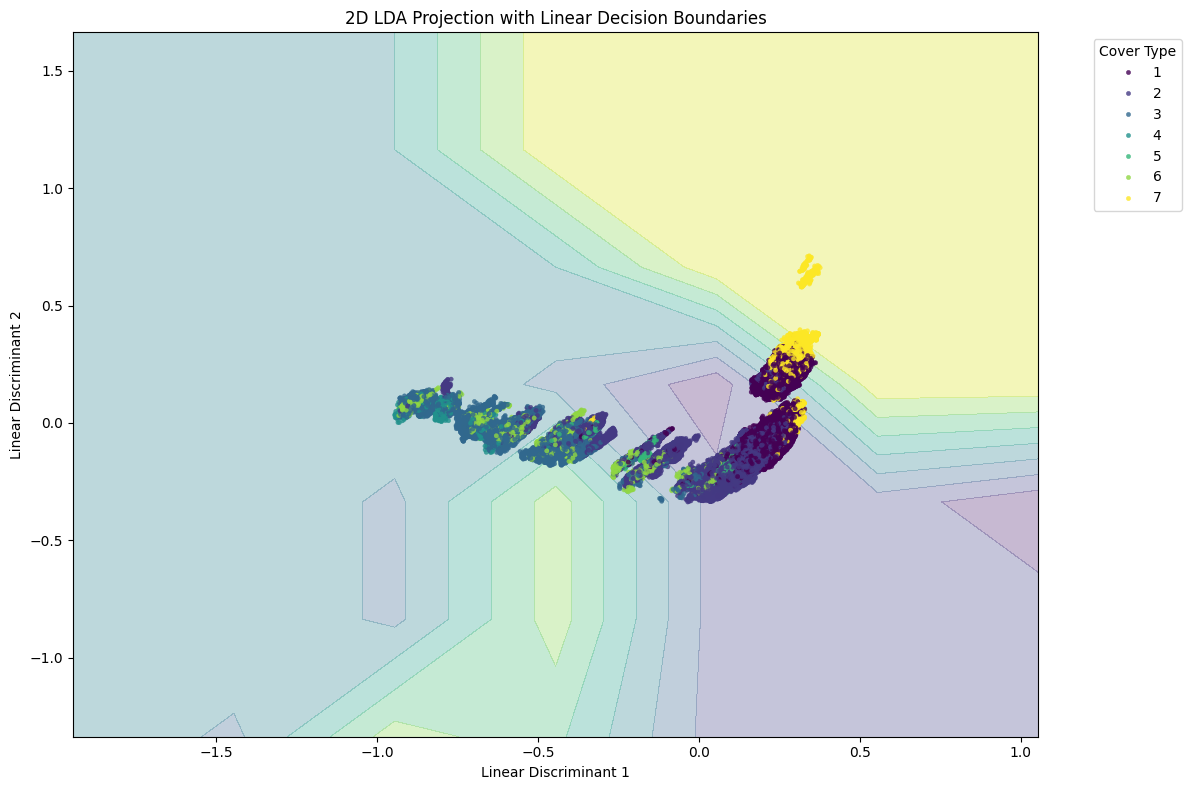

In [19]:
print("Plotting 2D Decision Boundaries ...")
plot_lda_2d(X_train_processed, y_train_np)

### 2.4 When to use LDA vs. QDA
**LDA:** Linear Discriminant Analysis (LDA) is a generative classifier based on Bayes’ theorem that assumes each class follows a multivariate Gaussian distribution with a **shared covariance matrix** ($\Sigma_k = \Sigma$). This simplifying assumption eliminates quadratic terms in the discriminant function, resulting in **linear decision boundaries**. The classification score is given by
$$\delta_k(x) = x \Sigma^{-1} \mu_k^T - \frac{1}{2} \mu_k \Sigma^{-1} \mu_k^T + \log(P(k))$$
Because LDA estimates a single covariance matrix, its parameter complexity scales linearly as $\mathcal{O}(Kd)$, making it statistically efficient. This constraint acts as an implicit regularizer, so LDA is generally preferred when the sample size $N$ is small relative to the feature dimension $d$, or when class covariances are similar.

**QDA:** Quadratic Discriminant Analysis (QDA) extends LDA by allowing each class to have its own **distinct covariance matrix** ($\Sigma_k \neq \Sigma_j$), while still assuming Gaussian class-conditional distributions. This added flexibility preserves quadratic terms in the discriminant function, producing **quadratic decision boundaries** (e.g., ellipses or hyperbolas). The classification score is
$$\delta_k(x) = -\frac{1}{2} \log |\Sigma_k| - \frac{1}{2} (x - \mu_k) \Sigma_k^{-1} (x - \mu_k)^T + \log(P(k))$$
QDA has significantly higher parameter complexity, scaling as $\mathcal{O}(Kd^2)$, since it estimates a full covariance matrix per class. While this reduces bias and allows modeling heterogeneous feature relationships across classes, it increases variance and risk of overfitting. Therefore, QDA is most appropriate when $N \gg d$ and when class-specific covariance structures differ substantially.


## **Task 3: Perceptron & Regularization**

### 3.1 Perceptron Algorithm & Convergence
The Perceptron is a linear binary classifier that updates its weights iteratively based on misclassifications. According to the Perceptron Convergence Theorem, if a dataset is strictly linearly separable, the algorithm is guaranteed to find a separating hyperplane and converge (error rate reaches exactly zero) in a finite number of steps. Conversely, if the classes overlap or the data is non-linearly separable (such as an XOR pattern or concentric circles), the boundary continuously oscillates.

In [20]:
class Perceptron:
    """An implementation of the standard Perceptron algorithm."""
    def __init__(self, learning_rate=0.1, max_iter=1000):
        self.learning_rate = learning_rate
        self.max_iter = max_iter
        self.weights = None
        self.bias = 0
        self.errors_per_epoch = []
        
    def fit(self, X, y):
        # Perceptron expects targets in {-1, 1}
        y_mod = np.where(y <= 0, -1, 1)
        N, D = X.shape
        self.weights = np.zeros(D)
        self.bias = 0
        self.errors_per_epoch = []
        
        for epoch in range(self.max_iter):
            errors = 0
            for xi, target in zip(X, y_mod):
                activation = np.dot(xi, self.weights) + self.bias
                if target * activation <= 0:
                    self.weights += self.learning_rate * target * xi
                    self.bias += self.learning_rate * target
                    errors += 1
            self.errors_per_epoch.append(errors)
            if errors == 0:
                break 
                
    def predict(self, X):
        activation = np.dot(X, self.weights) + self.bias
        return np.where(activation >= 0, 1, 0)

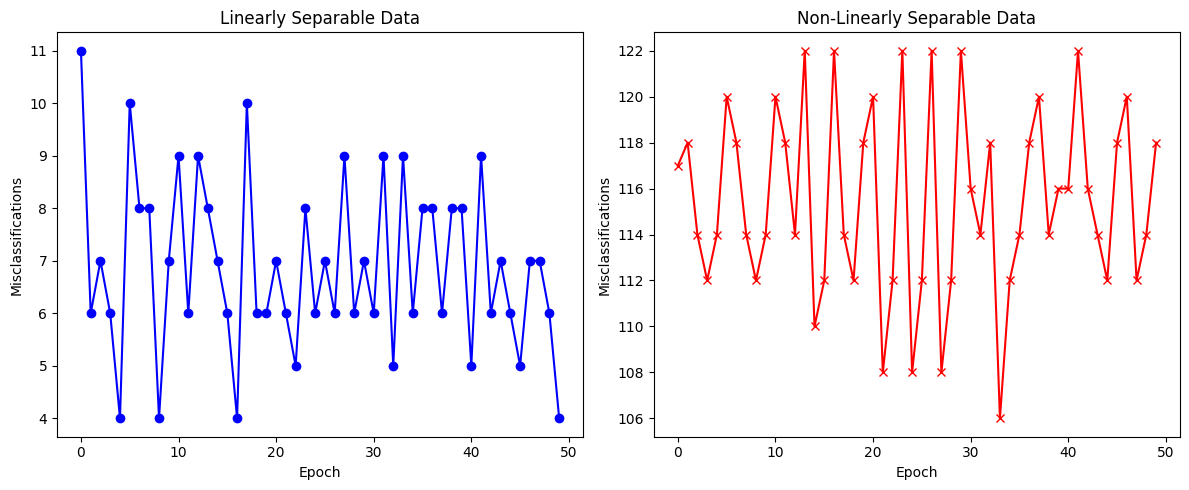

In [21]:
def demonstrate_perceptron():
    """Demonstrates Perceptron convergence on separable vs non-separable data"""

    # 1. Linearly Separable Data
    X_sep, y_sep = make_classification(n_samples=200, n_features=2, n_redundant=0, 
                                       n_clusters_per_class=1, random_state=SEED, class_sep=2.0)
    # 2. Non-Linearly Separable Data
    X_non_sep, y_non_sep = make_circles(n_samples=200, factor=0.5, noise=0.1, random_state=SEED)
    
    p_sep = Perceptron(learning_rate=0.1, max_iter=50)
    p_sep.fit(X_sep, y_sep)
    
    p_non_sep = Perceptron(learning_rate=0.1, max_iter=50)
    p_non_sep.fit(X_non_sep, y_non_sep)
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    axes[0].plot(p_sep.errors_per_epoch, marker='o', color='blue')
    axes[0].set_title('Linearly Separable Data')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Misclassifications')
    
    axes[1].plot(p_non_sep.errors_per_epoch, marker='x', color='red')
    axes[1].set_title('Non-Linearly Separable Data')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Misclassifications')
    
    plt.tight_layout()
    plt.show()

demonstrate_perceptron()

### 3.2 L1 vs. L2 Regularization & Sparsity Analysis
Regularization aims to prevent overfitting by penalizing large model parameters. We implemented two variants within our custom Logistic Regression:
* **L1 Regularization (Lasso):** Applies an absolute value penalty: $\lambda \sum |w_i|$. Because the L1 penalty term creates a diamond-shaped constraint region in the parameter space, the gradient descent loss contours often intersect the constraint region exactly at the axes. This aggressively drives less important feature weights exactly to zero, establishing L1 as an inherent feature selector.
* **L2 Regularization (Ridge):** Applies a squared penalty: $\frac{\lambda}{2} \sum w_i^2$. The circular constraint region of L2 smoothly shrinks all weights toward zero proportionally, but rarely forces them to be exactly zero. 


In [22]:
class LogisticRegression:
    """
    An implementation of Logistic Regression supporting:
    - Binary classification via Gradient Descent and Newton-Raphson.
    - Multiclass classification via Gradient Descent (Softmax).
    - L1 and L2 Regularization.
    """
    def __init__(self, learning_rate: float = 0.01, max_iter: int = 100, tol: float = 1e-4, penalty=None, lambda_reg=0.1):
        self.learning_rate = learning_rate
        self.max_iter = max_iter
        self.tol = tol
        self.penalty = penalty
        self.lambda_reg = lambda_reg
        self.weights = None
        self.history = {'loss': [], 'time': []}
        self.epsilon = 1e-15
        self.classes_ = None
        
    def _sigmoid(self, z):
        return 1 / (1 + np.exp(-np.clip(z, -250, 250))) 
    
    def _softmax(self, z):
        exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))
        return exp_z / np.sum(exp_z, axis=1, keepdims=True)
    
    def _add_intercept(self, X):
        return np.hstack((np.ones((X.shape[0], 1)), X))
    
    def fit_gd_multiclass(self, X, y):
        X_pad = self._add_intercept(X)
        N, D = X_pad.shape
        self.classes_ = np.unique(y)
        K = len(self.classes_)
        
        class_to_idx = {c: i for i, c in enumerate(self.classes_)}
        y_idx = np.array([class_to_idx[label] for label in y])
        
        y_one_hot = np.zeros((N, K))
        y_one_hot[np.arange(N), y_idx] = 1
        
        self.weights = np.zeros((D, K))
        start_time = time.time()
        
        for i in range(self.max_iter):
            z = np.dot(X_pad, self.weights)
            y_pred = self._softmax(z)
            
            # 1. Base loss and unregularized gradient
            loss = -np.sum(y_one_hot * np.log(y_pred + self.epsilon)) / N
            gradient = np.dot(X_pad.T, (y_pred - y_one_hot)) / N
            
            # 2. Add Regularization Loss (for tracking) and L2 Gradient
            if self.penalty == 'l2':
                loss += (self.lambda_reg / 2) * np.sum(self.weights[1:, :] ** 2)
                gradient[1:, :] += self.lambda_reg * self.weights[1:, :]
            elif self.penalty == 'l1':
                loss += self.lambda_reg * np.sum(np.abs(self.weights[1:, :]))
                
            # 3. Standard Gradient Descent Step
            self.weights -= self.learning_rate * gradient
            
            # 4. Apply Proximal Operator (Soft-Thresholding) for L1
            if self.penalty == 'l1':
                threshold_val = self.learning_rate * self.lambda_reg
                w_reg = self.weights[1:, :]
                
                # Soft-thresholding formula: sign(w) * max(|w| - threshold, 0)
                self.weights[1:, :] = np.sign(w_reg) * np.maximum(np.abs(w_reg) - threshold_val, 0)
            
            self.history['loss'].append(loss)
            self.history['time'].append(time.time() - start_time)
            
            if np.linalg.norm(gradient) < self.tol:
                break
                
        return self

    def predict_proba(self, X):
        X_pad = self._add_intercept(X)
        if self.weights.ndim == 1:
            return self._sigmoid(np.dot(X_pad, self.weights))
        else:
            return self._softmax(np.dot(X_pad, self.weights))
            
    def predict(self, X, threshold=0.5):
        probs = self.predict_proba(X)
        if self.weights.ndim == 1:
            return (probs >= threshold).astype(int)
        else:
            class_indices = np.argmax(probs, axis=1)
            return self.classes_[class_indices]

In [23]:
def analyze_regularization_sparsity(X_train, y_train, threshold = 1e-4 ):
    """Compares the sparsity of weights between L1 and L2 regularization."""
    log_l1 = LogisticRegression(penalty='l1', lambda_reg=0.5, learning_rate=0.1, max_iter=200)
    log_l1.fit_gd_multiclass(X_train, y_train)
    
    log_l2 = LogisticRegression(penalty='l2', lambda_reg=0.5, learning_rate=0.1, max_iter=200)
    log_l2.fit_gd_multiclass(X_train, y_train)
    
    # Exclude bias
    zero_weights_l1 = np.sum(np.abs(log_l1.weights) < threshold)
    zero_weights_l2 = np.sum(np.abs(log_l2.weights) < threshold)
    total_weights = log_l1.weights.size
    assert log_l1.weights.size == log_l2.weights.size
    
    print(f"Total Weights: {total_weights}")
    print(f"Near-Zero Weights (L1): {zero_weights_l1} (Feature selection effect)")
    print(f"Near-Zero Weights (L2): {zero_weights_l2} (Shrinkage effect)")

analyze_regularization_sparsity(X_train_processed, y_train)

Total Weights: 399
Near-Zero Weights (L1): 392 (Feature selection effect)
Near-Zero Weights (L2): 42 (Shrinkage effect)


### 3.2 Stratified 5-Fold Cross Validation

Standard cross-validation can introduce variance if the randomly sampled folds unbalance the class distributions. Stratified CV preserves the proportion of target classes in both the training and validation subsets for each fold. This is exceptionally critical for datasets like Covertype, which features highly disproportionate class frequencies, ensuring our macro-F1 evaluation metric remains reliable across the hyperparameter grid.

In [24]:
def tune_regularization(
    X,
    y,
    lambda_grid=(0.001, 0.01, 0.1, 1.0, 10.0),
    penalty='l2',
    learning_rate=0.1,
    max_iter=100,
):
    """Uses Stratified 5-Fold CV to find the best lambda and returns tuning details."""
    from sklearn.metrics import precision_score, recall_score

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

    best_lambda = None
    best_score = -1.0
    cv_table = []

    X_arr = X if isinstance(X, np.ndarray) else X.to_numpy()
    y_arr = y if isinstance(y, np.ndarray) else y.to_numpy()

    for lam in lambda_grid:
        print(f"Train model with lambda = {lam}")
        fold_acc = []
        fold_precision = []
        fold_recall = []
        fold_f1 = []

        for train_idx, val_idx in skf.split(X_arr, y_arr):
            X_tr, X_va = X_arr[train_idx], X_arr[val_idx]
            y_tr, y_va = y_arr[train_idx], y_arr[val_idx]

            model = LogisticRegression(
                penalty=penalty,
                lambda_reg=lam,
                learning_rate=learning_rate,
                max_iter=max_iter,
            )
            model.fit_gd_multiclass(X_tr, y_tr)

            y_pred = model.predict(X_va)
            fold_acc.append(float(np.mean(y_pred == y_va)))
            fold_precision.append(float(precision_score(y_va, y_pred, average='macro', zero_division=0)))
            fold_recall.append(float(recall_score(y_va, y_pred, average='macro', zero_division=0)))
            fold_f1.append(float(f1_score(y_va, y_pred, average='macro', zero_division=0)))

        metrics_row = {
            'penalty': penalty,
            'lambda': float(lam),
            'accuracy_mean': float(np.mean(fold_acc)),
            'accuracy_std': float(np.std(fold_acc)),
            'precision_macro_mean': float(np.mean(fold_precision)),
            'precision_macro_std': float(np.std(fold_precision)),
            'recall_macro_mean': float(np.mean(fold_recall)),
            'recall_macro_std': float(np.std(fold_recall)),
            'macro_f1_mean': float(np.mean(fold_f1)),
            'macro_f1_std': float(np.std(fold_f1)),
        }
        cv_table.append(metrics_row)

        if metrics_row['macro_f1_mean'] > best_score:
            best_score = metrics_row['macro_f1_mean']
            best_lambda = lam

    print(f"Best parameter (lambda): {best_lambda}")
    print(f"Best Macro-F1 Score: {best_score:.4f}")

    final_model = LogisticRegression(
        penalty=penalty,
        lambda_reg=best_lambda,
        learning_rate=learning_rate,
        max_iter=200,
    )
    final_model.fit_gd_multiclass(X_arr, y_arr)

    return {
        'penalty': penalty,
        'best_lambda': float(best_lambda),
        'best_macro_f1_mean': float(best_score),
        'cv_table': cv_table,
        'final_model': final_model,
    }

# X_temp_raw is train + val from the original dataset (80%).
X_processed = preprocess_pipeline.fit_transform(X_temp_raw)
y_temp_np = y_temp.to_numpy()

lambda_tuning_l1 = tune_regularization(X_processed, y_temp_np, penalty='l1')
lambda_tuning_l2 = tune_regularization(X_processed, y_temp_np, penalty='l2')

Train model with lambda = 0.001
Train model with lambda = 0.01
Train model with lambda = 0.1
Train model with lambda = 1.0
Train model with lambda = 10.0
Best parameter (lambda): 0.001
Best Macro-F1 Score: 0.2737
Train model with lambda = 0.001
Train model with lambda = 0.01
Train model with lambda = 0.1
Train model with lambda = 1.0
Train model with lambda = 10.0
Best parameter (lambda): 0.001
Best Macro-F1 Score: 0.2749


### 3.3 Custom Class-Weighted Loss Calculation
In severely imbalanced datasets, standard Cross-Entropy implicitly biases the model toward majority classes because their sheer volume dominates the gradient. To counteract this, we implemented a custom class-weighted loss calculation:
$$E = -\sum_{n}\sum_{k} c_k t_{nk} \ln y_{nk}$$
Where $t_{nk}$ is the true binary indicator for class $k$, $y_{nk}$ is the predicted probability, and the class weight $c_k \propto N/N_k$ artificially inflates the penalty when the model misclassifies a minority class. This mathematically forces the algorithm to prioritize the sparse classes proportionally, shifting the decision boundaries to maximize overall macro accuracy rather than simply favoring the mode.

In [25]:
def class_weighted_cross_entropy(y_true, y_pred_proba, class_weights_dict, epsilon = 1e-15 ):
    """
    Computes the custom class-weighted multiclass cross-entropy loss:
    E = - SUM( c_k * t_nk * ln(y_nk) )
    """
    N, K = y_pred_proba.shape
    y_pred_proba = np.clip(y_pred_proba, epsilon, 1 - epsilon)
    weight_array = np.array([class_weights_dict.get(k, 1.0) for k in range(K)])
    y_one_hot = np.zeros((N, K))
    y_one_hot[np.arange(N), y_true] = 1
    weighted_log_probs = weight_array * y_one_hot * np.log(y_pred_proba)
    loss = -np.sum(weighted_log_probs) / N
    
    return loss

### Export Artifacts for Notebook 04
Cell này lưu các artifact cần thiết cho notebook 04.

In [26]:
import os
import joblib
import numpy as np

artifacts_dir = "../results"
os.makedirs(artifacts_dir, exist_ok=True)

seed_value = int(globals().get('SEED', 42))

artifacts = {
    "seed": seed_value,
    "X_train_processed": X_train_processed,
    "X_val_processed": X_val_processed,
    "X_test_processed": X_test_processed,
    "y_train": y_train_np,
    "y_val": y_val_np,
    "y_test": y_test_np,
    "class_labels": np.sort(np.unique(y_train_np)),
    "class_weight_dict": class_weight_dict,
    "feature_names_processed": continuous_features_final + binary_cols,
    "shapes": {
        "X_train_processed": tuple(X_train_processed.shape),
        "X_val_processed": tuple(X_val_processed.shape),
        "X_test_processed": tuple(X_test_processed.shape),
        "y_train": tuple(y_train_np.shape),
        "y_val": tuple(y_val_np.shape),
        "y_test": tuple(y_test_np.shape),
    },
}

# ===== Task 1 =====
if "multiclass_results" in globals():
    artifacts["multiclass_results"] = multiclass_results

if "multiclass_val_predictions" in globals():
    artifacts["multiclass_val_predictions"] = {
        k: np.asarray(v) for k, v in multiclass_val_predictions.items()
    }

if "multiclass_models" in globals():
    multiclass_test_predictions = {}
    multiclass_test_probabilities = {}

    for model_name, model_obj in multiclass_models.items():
        try:
            multiclass_test_predictions[model_name] = np.asarray(model_obj.predict(X_test_processed))
        except Exception as e:
            print(f"[WARN] Cannot create test predictions for {model_name}: {e}")

        if hasattr(model_obj, 'predict_proba'):
            try:
                multiclass_test_probabilities[model_name] = np.asarray(model_obj.predict_proba(X_test_processed))
            except Exception as e:
                print(f"[WARN] Cannot create test probabilities for {model_name}: {e}")

    if multiclass_test_predictions:
        artifacts["multiclass_test_predictions"] = multiclass_test_predictions
    if multiclass_test_probabilities:
        artifacts["multiclass_test_probabilities"] = multiclass_test_probabilities

if "gd_binary_model" in globals() and hasattr(gd_binary_model, "history"):
    artifacts["gd_binary_loss_history"] = gd_binary_model.history
    try:
        artifacts["gd_binary_test_proba"] = np.asarray(gd_binary_model.predict_proba(X_test_processed))
    except Exception as e:
        print(f"[WARN] Cannot export gd binary probabilities: {e}")

if "newton_binary_model" in globals() and hasattr(newton_binary_model, "history"):
    artifacts["newton_binary_loss_history"] = newton_binary_model.history
    try:
        artifacts["newton_binary_test_proba"] = np.asarray(newton_binary_model.predict_proba(X_test_processed))
    except Exception as e:
        print(f"[WARN] Cannot export newton binary probabilities: {e}")

# ===== Task 2 =====
if "preds_lda" in globals():
    artifacts["preds_lda"] = np.asarray(preds_lda)
if "preds_qda" in globals():
    artifacts["preds_qda"] = np.asarray(preds_qda)
if "proba_lda" in globals():
    artifacts["proba_lda"] = np.asarray(proba_lda)
if "proba_qda" in globals():
    artifacts["proba_qda"] = np.asarray(proba_qda)
if "fisher_scores" in globals():
    artifacts["fisher_scores"] = np.asarray(fisher_scores)
if "top_indices" in globals():
    artifacts["fisher_top_indices"] = np.asarray(top_indices)

# ===== Task 3: only model outputs used in evaluation =====
if "lambda_tuning_l1" in globals():
    artifacts["lambda_tuning_l1"] = {
        "penalty": lambda_tuning_l1["penalty"],
        "best_lambda": lambda_tuning_l1["best_lambda"],
        "best_macro_f1_mean": lambda_tuning_l1["best_macro_f1_mean"],
        "cv_table": lambda_tuning_l1["cv_table"],
    }
if "lambda_tuning_l2" in globals():
    artifacts["lambda_tuning_l2"] = {
        "penalty": lambda_tuning_l2["penalty"],
        "best_lambda": lambda_tuning_l2["best_lambda"],
        "best_macro_f1_mean": lambda_tuning_l2["best_macro_f1_mean"],
        "cv_table": lambda_tuning_l2["cv_table"],
    }

task3_custom_test_predictions = {}
task3_custom_test_probabilities = {}

if "lambda_tuning_l1" in globals() and "final_model" in lambda_tuning_l1:
    try:
        l1_model = lambda_tuning_l1["final_model"]
        task3_custom_test_predictions["Regularized Logistic L1 (custom from 03)"] = np.asarray(
            l1_model.predict(X_test_processed)
        )
        task3_custom_test_probabilities["Regularized Logistic L1 (custom from 03)"] = np.asarray(
            l1_model.predict_proba(X_test_processed)
        )
    except Exception as e:
        print(f"[WARN] Cannot export custom L1 tuned model outputs: {e}")

if "lambda_tuning_l2" in globals() and "final_model" in lambda_tuning_l2:
    try:
        l2_model = lambda_tuning_l2["final_model"]
        task3_custom_test_predictions["Regularized Logistic L2 (custom from 03)"] = np.asarray(
            l2_model.predict(X_test_processed)
        )
        task3_custom_test_probabilities["Regularized Logistic L2 (custom from 03)"] = np.asarray(
            l2_model.predict_proba(X_test_processed)
        )
    except Exception as e:
        print(f"[WARN] Cannot export custom L2 tuned model outputs: {e}")

if task3_custom_test_predictions:
    artifacts["task3_custom_test_predictions"] = task3_custom_test_predictions
if task3_custom_test_probabilities:
    artifacts["task3_custom_test_probabilities"] = task3_custom_test_probabilities

# Coverage chỉ cho các model được đánh giá trong notebook 04
artifacts["task_coverage"] = {
    "task1_multiclass_results": "multiclass_results" in globals(),
    "task1_binary_history": ("gd_binary_model" in globals()) and ("newton_binary_model" in globals()),
    "task1_multiclass_test_predictions": "multiclass_models" in globals(),
    "task2_preds_lda": "preds_lda" in globals(),
    "task2_preds_qda": "preds_qda" in globals(),
    "task2_fisher_scores": "fisher_scores" in globals(),
    "task3_lambda_tuning_l1": "lambda_tuning_l1" in globals(),
    "task3_lambda_tuning_l2": "lambda_tuning_l2" in globals(),
    "task3_custom_test_predictions": bool(task3_custom_test_predictions),
}

required_custom_keys = [
    "multiclass_test_predictions",
    "preds_lda",
    "preds_qda",
    "gd_binary_loss_history",
    "newton_binary_loss_history",
]
print("Missing required custom keys:", [k for k in required_custom_keys if k not in artifacts])

artifacts_path = os.path.join(artifacts_dir, "evaluation_artifacts_from_03.joblib")
joblib.dump(artifacts, artifacts_path)

print(f"Saved artifacts to: {artifacts_path}")
print("Saved keys:")
print(sorted(list(artifacts.keys())))
print("Task coverage:")
print(artifacts["task_coverage"])

Missing required custom keys: []
Saved artifacts to: ../results\evaluation_artifacts_from_03.joblib
Saved keys:
['X_test_processed', 'X_train_processed', 'X_val_processed', 'class_labels', 'class_weight_dict', 'feature_names_processed', 'fisher_scores', 'fisher_top_indices', 'gd_binary_loss_history', 'gd_binary_test_proba', 'lambda_tuning_l1', 'lambda_tuning_l2', 'multiclass_results', 'multiclass_test_predictions', 'multiclass_test_probabilities', 'multiclass_val_predictions', 'newton_binary_loss_history', 'newton_binary_test_proba', 'preds_lda', 'preds_qda', 'proba_lda', 'proba_qda', 'seed', 'shapes', 'task3_custom_test_predictions', 'task3_custom_test_probabilities', 'task_coverage', 'y_test', 'y_train', 'y_val']
Task coverage:
{'task1_multiclass_results': True, 'task1_binary_history': True, 'task1_multiclass_test_predictions': True, 'task2_preds_lda': True, 'task2_preds_qda': True, 'task2_fisher_scores': True, 'task3_lambda_tuning_l1': True, 'task3_lambda_tuning_l2': True, 'task3_cu